In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import shutil
import matplotlib.pyplot as plt


In [2]:
df = pd.read_pickle('IDRome_DB_reanalyzed_entanglement.pkl')

In [3]:
# Assign categories using apply
"""
1: Weak Polyampholytes & polyelectrolytes
2. Boundary
3. Strong Polyampholytes
4. Strong Polyelectrolytes
-1: Uncategorized.
"""
df['category'] = df.apply(
    lambda row: 1 if row['fcr'] < 0.25 and np.abs(row['ncpr']) < 0.25 else
                2 if 0.25 <= row['fcr'] <= 0.35 and np.abs(row['ncpr']) <= 0.35 else
                3 if row['fcr'] > 0.35 and np.abs(row['ncpr']) <= 0.35 else
                4 if row['fcr'] > 0.35 and np.abs(row['ncpr']) > 0.35 else
                -1,
    axis=1
)

In [4]:
df

,seq_name,UniProt_ID,N,nu,Rg/nm,Ree/nm,fasta,is_btw_folded,is_nterm,is_cterm,...,N_FL,protein_name,gene_name,f+,f-,fcr,ncpr,dir_path,ent_prob,category
0,A0A024RBG1_145_181,A0A024RBG1,37,0.558,1.606731,3.845104,KLGCSPANGNSTVPSLPDNNALFVTAAQTSGLPSSVR,False,False,True,...,181,Diphosphoinositol polyphosphate phosphohydrola...,NUDT4B,0.027027,0.027027,0.054054,0.000000,A0/A0/24/RBG1/145_181,0.001,1
1,A0A075B6T7_1_32,A0A075B6T7,32,0.525,1.447131,3.385064,MAFWLRSLGLHFRPHLGRRMESFLGGVLLILW,False,True,False,...,132,T cell receptor alpha variable 6,TRAV6,0.156250,0.031250,0.187500,0.125000,A0/A0/75/B6T7/1_32,0.000,1
2,A0A087WTH1_1_67,A0A087WTH1,67,0.532,2.246105,5.295387,MEDEEKAVEILGNTEAAHPPSPIRCCWLRLRCLAATSIICGCSCLG...,False,True,False,...,108,Transmembrane protein 265,TMEM265,0.134328,0.149254,0.283582,-0.014925,A0/A0/87/WTH1/1_67,0.012,2
3,A0A087WTH5_1_132,A0A087WTH5,132,0.496,3.038320,7.131916,MPRMILSNTTAVTPFLTKLWQETVQQGGNMSGLARRSPRSGDGKLE...,False,True,True,...,132,Putative potassium voltage-gated channel subfa...,KCNE1B,0.113636,0.098485,0.212121,0.015152,A0/A0/87/WTH5/1_132,0.094,1
4,A0A087WV53_1_46,A0A087WV53,46,0.567,1.880940,4.603256,MSKAAPAKKPVAVAPAPGCTLDINDPQVQSAAIRIQASYRGHRSRK,False,True,False,...,238,SPEG neighbor protein,SPEGNB,0.195652,0.043478,0.239130,0.152174,A0/A0/87/WV53/1_46,0.007,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27618,Q9Y6Z4_1_181,Q9Y6Z4,181,0.493,3.790272,8.597289,MGDIFKNNGVLQGRLRAVACAPHCFGPRLRCLHHDQGLTELAWGTW...,False,True,True,...,181,Putative uncharacterized protein KIF25-AS1,KIF25-AS1,0.121547,0.060773,0.182320,0.060773,Q9/Y6/Z4/1_181,0.138,1
27619,Q9Y6Z5_1_254,Q9Y6Z5,254,0.528,4.586494,10.810353,MGAAGSDGRCCVRSGRAGTGGAGSKWVVMDLWTGGAGSRRAVLGPD...,False,True,True,...,254,Putative uncharacterized protein AFDN-DT,AFDN-DT,0.149606,0.035433,0.185039,0.114173,Q9/Y6/Z5/1_254,0.236,1
27620,Q9Y6Z7_1_109,Q9Y6Z7,109,0.546,3.012739,7.121029,MNGFASLLRRNQFILLVLFLLQIQSLGLDIDSRPTAEVCATHTISP...,False,True,False,...,277,Collectin-10,COLEC10,0.146789,0.128440,0.275229,0.018349,Q9/Y6/Z7/1_109,0.035,2
27621,W6CW81_1_113,W6CW81,113,0.519,2.943975,6.978634,MESKYKEILLLTSLDNITDEELDRFKCFLPDEFNIATGKLHTLNST...,False,True,True,...,113,Pyrin domain-containing protein 5,PYDC5,0.123894,0.150442,0.274336,-0.026549,W6/CW/81/1_113,0.054,2


In [8]:
print(f"Number of unique proteins: {len(df['UniProt_ID'].unique())}")

Number of unique proteins: 15297


In [9]:
df[df['category']==4]

,seq_name,UniProt_ID,N,nu,Rg/nm,Ree/nm,fasta,is_btw_folded,is_nterm,is_cterm,...,N_FL,protein_name,gene_name,f+,f-,fcr,ncpr,dir_path,ent_prob,category
148,A0A494C086_275_341,A0A494C086,67,0.634,2.876960,7.307668,GKTRSRIPLLRKRWFQLGRSMNPRARKNRSRIPLLRKRRFQLGRSM...,False,False,False,...,402,Putative speedy protein E21,SPDYE21,0.388060,0.000000,0.388060,0.388060,A0/A4/94/C086/275_341,0.001,4
225,A1L162_127_156,A1L162,30,0.670,1.680408,4.434263,NSDEDSSGESKGESDEELSDESSDEGEDGS,False,False,True,...,156,Glutamate-rich protein 2,ERICH2,0.033333,0.500000,0.533333,-0.466667,A1/L1/62/127_156,0.000,4
642,A6NIY4_279_342,A6NIY4,64,0.620,2.806667,7.025959,SRIPLLRKRWFQLGRSMNPRARKKRSRIPLLRKRRFQLGRSMNPRA...,False,False,False,...,402,Speedy protein E5,SPDYE5,0.390625,0.000000,0.390625,0.390625,A6/NI/Y4/279_342,0.000,4
1041,B2RPK0_164_211,B2RPK0,48,0.289,1.652060,3.426710,AKGKPEAAKKGVVKAEKSKKKKEEEEDEEDEEDEEEEDEEDEEDDDDE,False,False,True,...,211,Putative high mobility group protein B1-like 1,HMGB1P1,0.208333,0.583333,0.791667,-0.395833,B2/RP/K0/164_211,0.032,4
1569,O14602_114_144,O14602,31,0.667,1.760443,4.564665,KINETDTFGPGDDDEIQFDDIGDDDEDIDDI,False,False,True,...,144,"Eukaryotic translation initiation factor 1A, Y...",EIF1AY,0.032258,0.516129,0.548387,-0.483871,O1/46/02/114_144,0.000,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26050,Q9UKY1_828_873,Q9UKY1,46,0.509,1.946305,4.668347,GIELFEENEEEDEVIDDQEEDEEETDDSDTWEPPRHVKRKLSKSDD,False,False,True,...,873,Zinc fingers and homeoboxes protein 1,ZHX1,0.108696,0.478261,0.586957,-0.391304,Q9/UK/Y1/828_873,0.012,4
26181,Q9ULJ8_617_672,Q9ULJ8,56,0.643,2.605948,6.591713,LEQHYAQYDADDDETGEYATDEEEDEVGPVLPGSDMAIEVFELPEN...,True,False,False,...,1098,Neurabin-1,PPP1R9A,0.000000,0.375000,0.375000,-0.375000,Q9/UL/J8/617_672,0.000,4
26259,Q9ULW3_1_39,Q9ULW3,39,0.630,1.992885,5.021713,MEAEESEKAATEQEPLEGTEQTLDAEEEQEESEEAACGS,False,True,False,...,272,Activator of basal transcription 1,ABT1,0.051282,0.410256,0.461538,-0.358974,Q9/UL/W3/1_39,0.000,4
26262,Q9ULW6_167_237,Q9ULW6,71,0.649,3.287336,8.459514,EYKSDSEDCDDEEMCHEEMYGNEEGMVHEYVDEDDGYEDYYYDYAV...,False,False,False,...,460,Nucleosome assembly protein 1-like 2,NAP1L2,0.028169,0.535211,0.563380,-0.507042,Q9/UL/W6/167_237,0.000,4


In [14]:
print(f"Percentage of sequence in region I-III: {100*(27623-135)/27623:.2f}%")
print(f"Percentage of sequence in region IV-V: {100*(135)/27623:.2f}%")

Percentage of sequence in region I-III: 99.51%
Percentage of sequence in region IV-V: 0.49%


In [15]:
df[df['ent_prob']>0]

,seq_name,UniProt_ID,N,nu,Rg/nm,Ree/nm,fasta,is_btw_folded,is_nterm,is_cterm,...,N_FL,protein_name,gene_name,f+,f-,fcr,ncpr,dir_path,ent_prob,category
0,A0A024RBG1_145_181,A0A024RBG1,37,0.558,1.606731,3.845104,KLGCSPANGNSTVPSLPDNNALFVTAAQTSGLPSSVR,False,False,True,...,181,Diphosphoinositol polyphosphate phosphohydrola...,NUDT4B,0.027027,0.027027,0.054054,0.000000,A0/A0/24/RBG1/145_181,0.001,1
2,A0A087WTH1_1_67,A0A087WTH1,67,0.532,2.246105,5.295387,MEDEEKAVEILGNTEAAHPPSPIRCCWLRLRCLAATSIICGCSCLG...,False,True,False,...,108,Transmembrane protein 265,TMEM265,0.134328,0.149254,0.283582,-0.014925,A0/A0/87/WTH1/1_67,0.012,2
3,A0A087WTH5_1_132,A0A087WTH5,132,0.496,3.038320,7.131916,MPRMILSNTTAVTPFLTKLWQETVQQGGNMSGLARRSPRSGDGKLE...,False,True,True,...,132,Putative potassium voltage-gated channel subfa...,KCNE1B,0.113636,0.098485,0.212121,0.015152,A0/A0/87/WTH5/1_132,0.094,1
4,A0A087WV53_1_46,A0A087WV53,46,0.567,1.880940,4.603256,MSKAAPAKKPVAVAPAPGCTLDINDPQVQSAAIRIQASYRGHRSRK,False,True,False,...,238,SPEG neighbor protein,SPEGNB,0.195652,0.043478,0.239130,0.152174,A0/A0/87/WV53/1_46,0.007,1
5,A0A087WVF3_214_549,A0A087WVF3,336,0.480,4.974665,11.354244,LASERHSLQGFHSPNGGTVQGLQDQQEHVVATSQPKTMGHQDKKDL...,False,False,True,...,549,TBC1 domain family member 3D,TBC1D3D,0.122024,0.095238,0.217262,0.026786,A0/A0/87/WVF3/214_549,0.444,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27618,Q9Y6Z4_1_181,Q9Y6Z4,181,0.493,3.790272,8.597289,MGDIFKNNGVLQGRLRAVACAPHCFGPRLRCLHHDQGLTELAWGTW...,False,True,True,...,181,Putative uncharacterized protein KIF25-AS1,KIF25-AS1,0.121547,0.060773,0.182320,0.060773,Q9/Y6/Z4/1_181,0.138,1
27619,Q9Y6Z5_1_254,Q9Y6Z5,254,0.528,4.586494,10.810353,MGAAGSDGRCCVRSGRAGTGGAGSKWVVMDLWTGGAGSRRAVLGPD...,False,True,True,...,254,Putative uncharacterized protein AFDN-DT,AFDN-DT,0.149606,0.035433,0.185039,0.114173,Q9/Y6/Z5/1_254,0.236,1
27620,Q9Y6Z7_1_109,Q9Y6Z7,109,0.546,3.012739,7.121029,MNGFASLLRRNQFILLVLFLLQIQSLGLDIDSRPTAEVCATHTISP...,False,True,False,...,277,Collectin-10,COLEC10,0.146789,0.128440,0.275229,0.018349,Q9/Y6/Z7/1_109,0.035,2
27621,W6CW81_1_113,W6CW81,113,0.519,2.943975,6.978634,MESKYKEILLLTSLDNITDEELDRFKCFLPDEFNIATGKLHTLNST...,False,True,True,...,113,Pyrin domain-containing protein 5,PYDC5,0.123894,0.150442,0.274336,-0.026549,W6/CW/81/1_113,0.054,2


In [16]:
df[df['ent_prob']>=0.5]

,seq_name,UniProt_ID,N,nu,Rg/nm,Ree/nm,fasta,is_btw_folded,is_nterm,is_cterm,...,N_FL,protein_name,gene_name,f+,f-,fcr,ncpr,dir_path,ent_prob,category
19,A0A096LP49_1_634,A0A096LP49,634,0.505,7.632706,17.640240,MPTLVVGTPPTCLGDTPQPCHKNSQRQGPFSHGAPGRAADWKAVAK...,False,True,False,...,1063,Coiled-coil domain-containing protein 187,CCDC187,0.149842,0.088328,0.238170,0.061514,A0/A0/96/LP49/1_634,0.584,1
26,A0A0B4J2F2_350_783,A0A0B4J2F2,434,0.493,5.818978,13.276718,NAQCARPGPARQPRPRSSDLSGLEVPQEGLSTDPFRPALLCPQPQT...,False,False,True,...,783,Putative serine/threonine-protein kinase SIK1B,SIK1B,0.069124,0.076037,0.145161,-0.006912,A0/A0/B4/J2F2/350_783,0.512,1
36,A0A0J9YY54_151_714,A0A0J9YY54,564,0.516,6.970635,16.516365,RFPQAAPLAHEIMSGPQAEQNGAAACPLATEQQSDMVAMGTHANAQ...,False,False,True,...,714,Testis-expressed protein 13D,TEX13D,0.117021,0.118794,0.235816,-0.001773,A0/A0/J9/YY54/151_714,0.594,1
65,A0A1B0GTU1_94_805,A0A1B0GTU1,712,0.523,8.656051,20.124245,FLPPSKSVLPTVPESPEEEVKASQLSVQQNKLSVQSNTSPQLRSVM...,False,False,True,...,805,Zinc finger CCCH domain-containing protein 11B,ZC3H11B,0.148876,0.160112,0.308989,-0.011236,A0/A1/B0/GTU1/94_805,0.550,2
101,A0A1B0GVH6_1_325,A0A1B0GVH6,325,0.463,4.687799,10.368737,MFRKIHSIFNSSPQRKTAAESPFYEGASPAVKLIRSSSMYVVGDHG...,False,True,True,...,325,Uncharacterized protein C13orf42,C13orf42,0.163077,0.138462,0.301538,0.024615,A0/A1/B0/GVH6/1_325,0.525,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27367,Q9Y5V3_1_472,Q9Y5V3,472,0.510,6.412692,14.957994,MAQKMDCGAGLLGFQAEASVEDSALLMQTLMEAIQISEAPPTNQAT...,False,True,False,...,778,Melanoma-associated antigen D1,MAGED1,0.072034,0.074153,0.146186,-0.002119,Q9/Y5/V3/1_472,0.512,1
27543,Q9Y6N6_1021_1575,Q9Y6N6,555,0.503,7.200169,16.429855,KEEAAKLKARLTLTEGWLQGSDCGSPWGPLDILLGEAPRGDVYQGH...,False,False,True,...,1575,Laminin subunit gamma-3,LAMC3,0.126126,0.131532,0.257658,-0.005405,Q9/Y6/N6/1021_1575,0.560,2
27582,Q9Y6V0_3827_4498,Q9Y6V0,672,0.490,7.207406,16.541552,VAEDRDYMSDSEVSSTRPTRIESQHGIERPRTAPQTEFSQFIPPQT...,False,False,False,...,5142,Protein piccolo,PCLO,0.113095,0.117560,0.230655,-0.004464,Q9/Y6/V0/3827_4498,0.743,1
27598,Q9Y6X6_1209_1858,Q9Y6X6,650,0.504,7.626392,17.420021,RENDRLRSEMNAPYHKEKLEVRNMQEEGSKRTDDKSGPRHFHPSSM...,False,False,True,...,1858,Unconventional myosin-XVI,MYO16,0.109231,0.116923,0.226154,-0.007692,Q9/Y6/X6/1209_1858,0.666,1


In [18]:
print(f"percentage of seq with at least 1 entangled conformation: {100*len(df[df['ent_prob']>0])/len(df):.2f}%")
print(f"percentage of seq with >50% entangled conformation: {100*len(df[df['ent_prob']>=0.5])/len(df):.2f}%")

percentage of seq with at least 1 entangled conformation: 85.18%
percentage of seq with >50% entangled conformation: 3.58%


In [19]:
df[df['ent_prob']==0]

,seq_name,UniProt_ID,N,nu,Rg/nm,Ree/nm,fasta,is_btw_folded,is_nterm,is_cterm,...,N_FL,protein_name,gene_name,f+,f-,fcr,ncpr,dir_path,ent_prob,category
1,A0A075B6T7_1_32,A0A075B6T7,32,0.525,1.447131,3.385064,MAFWLRSLGLHFRPHLGRRMESFLGGVLLILW,False,True,False,...,132,T cell receptor alpha variable 6,TRAV6,0.156250,0.031250,0.187500,0.125000,A0/A0/75/B6T7/1_32,0.0,1
11,A0A087WXS9_1_50,A0A087WXS9,50,0.542,1.927965,4.625281,MDVVEVAGSWWAQEREDIIMKYEKGHRAGLPEDKGPKPFRSYNNNV...,False,True,False,...,549,TBC1 domain family member 3I,TBC1D3I,0.160000,0.180000,0.340000,-0.020000,A0/A0/87/WXS9/1_50,0.0,2
25,A0A0B4J2D5_1_36,A0A0B4J2D5,36,0.585,1.634511,3.967597,MAAVRALVASRLAAASAFTSLSPGGRTPSQRAALHL,False,True,False,...,268,Putative glutamine amidotransferase-like class...,GATD3B,0.138889,0.000000,0.138889,0.138889,A0/A0/B4/J2D5/1_36,0.0,1
27,A0A0B4J2F2_278_307,A0A0B4J2F2,30,0.570,1.443610,3.454023,MRAEPCLPGPACPAFSAHSYTSNLGDYDEQ,False,False,False,...,783,Putative serine/threonine-protein kinase SIK1B,SIK1B,0.033333,0.133333,0.166667,-0.100000,A0/A0/B4/J2F2/278_307,0.0,1
45,A0A0U1RRI6_254_287,A0A0U1RRI6,34,0.597,1.599510,4.004527,VGGGDPGEEAAEEHKAIHKTSSQSAPACPREQEQ,False,False,True,...,287,Centromere protein V-like protein 3,CENPVL3,0.088235,0.235294,0.323529,-0.147059,A0/A0/U1/RRI6/254_287,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27587,Q9Y6V7_451_483,Q9Y6V7,33,0.534,1.512897,3.514502,LKRQKAGRAGHKGRPPRTPSGSHSGPVPSQGLV,False,False,True,...,483,Probable ATP-dependent RNA helicase DDX49,DDX49,0.212121,0.030303,0.242424,0.181818,Q9/Y6/V7/451_483,0.0,1
27591,Q9Y6W6_283_320,Q9Y6W6,38,0.591,1.701365,4.157648,LCDNSLQLQECREVGGGASAASSLLPQPIPTTPDIENA,True,False,False,...,482,Dual specificity protein phosphatase 10,DUSP10,0.026316,0.131579,0.157895,-0.105263,Q9/Y6/W6/283_320,0.0,1
27592,Q9Y6W8_163_199,Q9Y6W8,37,0.538,1.623422,3.775193,WLTKKKYSSSVHDPNGEYMFMRAVNTAKKSRLTDVTL,False,False,True,...,199,Inducible T-cell costimulator,ICOS,0.189189,0.108108,0.297297,0.081081,Q9/Y6/W8/163_199,0.0,2
27605,Q9Y6X8_508_537,Q9Y6X8,30,0.594,1.455495,3.634896,KDQLAIAASRHGRTYHAYPDFAPQKFKEKT,False,False,False,...,837,Zinc fingers and homeoboxes protein 2,ZHX2,0.200000,0.100000,0.300000,0.100000,Q9/Y6/X8/508_537,0.0,2


In [20]:
print(f"percentage of seq do not populate any entangled conformation: {100*len(df[df['ent_prob']==0])/len(df):.2f}%")

percentage of seq do not populate any entangled conformation: 14.82%


## Matplotlib setup and data preparation

In [101]:

# Matplotlib settings for publication-quality plots
base_fontsize = 16
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

# Panel (a) Data Preparation
# Filter data for Panel (a): Control for N, exclude short segment
df_merged_N = df_merged[df_merged['N'] > 100].copy()

# Panel (b) Data Preparation
bin_width = 0.05
bins = pd.interval_range(start=0, end=0.66, freq=bin_width, closed='left')
df_merged_N['nu_bin'] = pd.cut(df_merged_N['nu'], bins=bins)

# Calculate the mean and SEM for each bin
grouped_data = df_merged_N.groupby('nu_bin').agg(
    mean_ent_prob=('ent_prob', 'mean'),
    sem_ent_prob=('ent_prob', 'sem')
).reset_index()

# Format bin labels and calculate bin midpoints
def format_bin_label(interval):
    left = f"{interval.left:.2f}".rstrip('0').rstrip('.')
    right = f"{interval.right:.2f}".rstrip('0').rstrip('.')
    return f"[{left}, {right})"

grouped_data['nu_bin'] = grouped_data['nu_bin'].apply(format_bin_label)
grouped_data['bin_midpoint'] = grouped_data['nu_bin'].apply(
    lambda x: (float(x.split(',')[0][1:]) + float(x.split(',')[1][:-1])) / 2
)

# Panel (c) Data Preparation
x = np.linspace(0, 1, 21)
line_x = np.linspace(0, 1, 100)  # Line data
line_y_1 = 7/6 * line_x - 7/6 * 0.35
line_y_1_masked = np.where(line_y_1 < 0.35, line_y_1, np.nan)
line_y_2 = 6/7 * line_x + 0.35
line_y_2_masked = np.where(line_y_2 < 0.65, line_y_2, np.nan)
line_y_3 = -line_x + 1
line_y_4 = -line_x + 0.35
line_y_5 = -line_x + 0.25

/var/folders/1f/m8_t8g414dz2d33zlncf3gv40000gn/T/ipykernel_72891/2968264326.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_merged_N.groupby('nu_bin').agg(


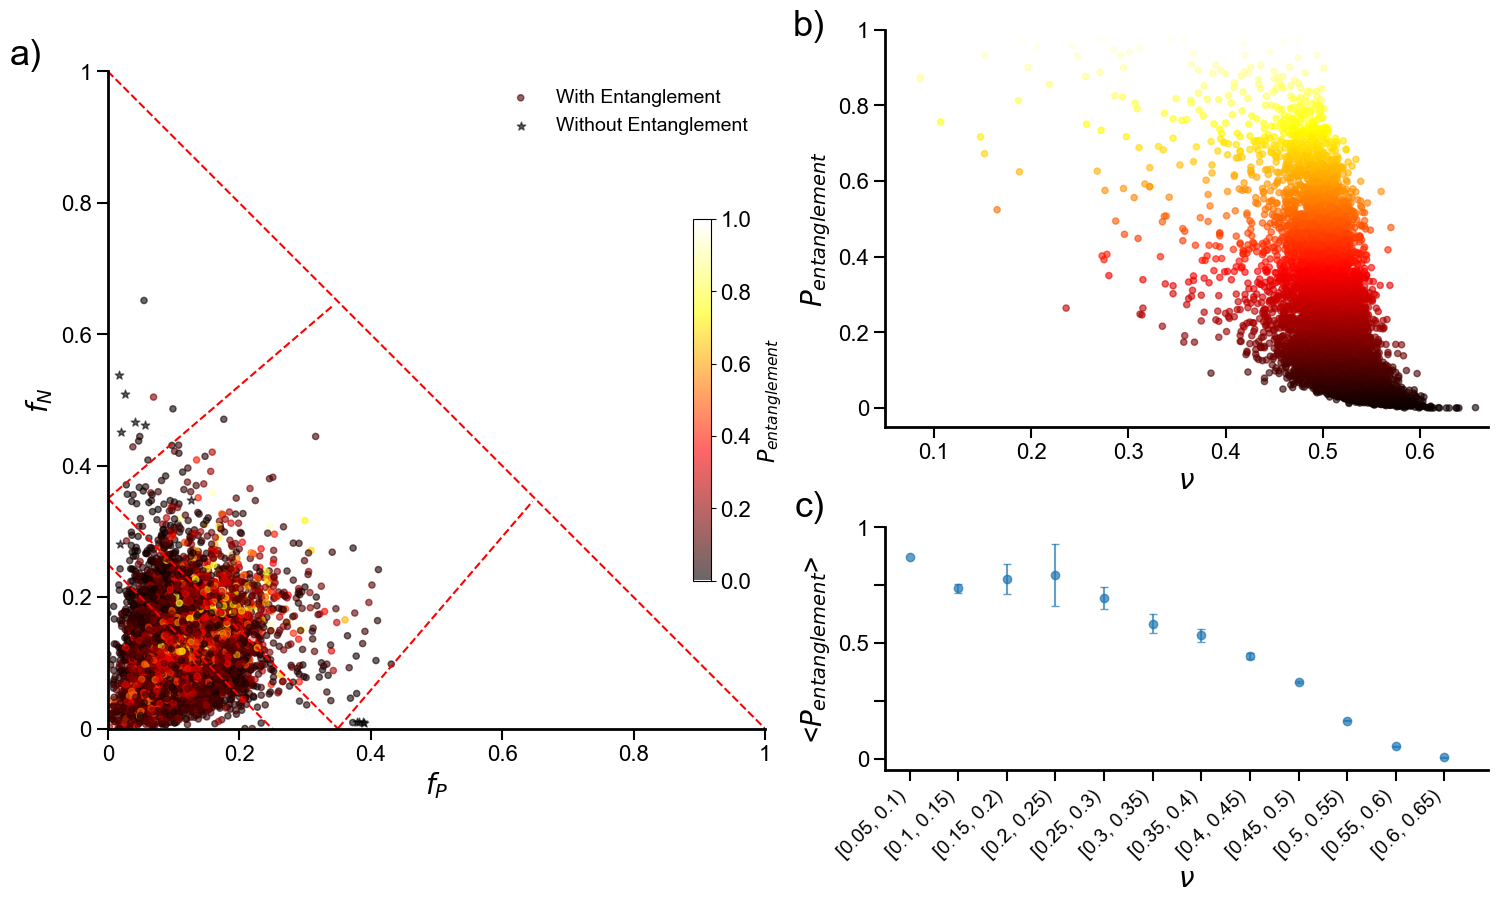

In [121]:
# Adjust the layout ratios to ensure proper centering
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(5, 2, height_ratios=[0.5, 2, 0.2, 1, 1], width_ratios=[1, 1])

# Panels
ax1 = fig.add_subplot(gs[0:4, 0])  # Centered Panel (a) spans full width
ax2 = fig.add_subplot(gs[0:2, 1])  # Panel (b)
ax3 = fig.add_subplot(gs[2:4, 1])  # Panel (c)

# Panel (a): Adjust placement and appearance
sc = ax1.scatter(
    idrome_w_ent['f+'], idrome_w_ent['f-'], 
    s=20, alpha=0.6, c=idrome_w_ent['ent_prob'], cmap='hot', label='With Entanglement'
)
ax1.scatter(
    idrome_wo_ent['f+'], idrome_wo_ent['f-'], 
    s=40, alpha=0.6, c='black', marker='*', label='Without Entanglement'
)
ax1.plot(line_x, line_y_1_masked, color='red', linestyle='--', linewidth=1.5)
ax1.plot(line_x, line_y_2_masked, color='red', linestyle='--', linewidth=1.5)
ax1.plot(line_x, line_y_3, color='red', linestyle='--', linewidth=1.5)
ax1.plot(line_x, line_y_4, color='red', linestyle='--', linewidth=1.5)
ax1.plot(line_x, line_y_5, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('$f_{P}$', fontsize=base_fontsize+4)
ax1.set_ylabel('$f_{N}$', fontsize=base_fontsize+4)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# yticks
general_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]  # Tick positions
general_ticklabels = ['0', '0.2', '0.4', '0.6', '0.8', '1']  # Only show labels for 0, 0.5, and 1
ax1.set_yticks(general_ticks)
ax1.set_yticklabels(general_ticklabels)
ax1.set_xticks(general_ticks)
ax1.set_xticklabels(general_ticklabels)
ax1.tick_params(labelsize=base_fontsize, length=8, width=1.5)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)
ax1.set_aspect('equal', adjustable='box')
ax1.legend(fontsize=base_fontsize - 2, loc='upper right', frameon=False)

# Add label for Panel (a)
ax1.text(-0.1, 1.05, 'a)', transform=ax1.transAxes, fontsize=base_fontsize+10, fontweight='regular', va='top', ha='right')



# Add colorbar to Panel (a)
cbar = fig.colorbar(sc, ax=ax1, orientation='vertical', fraction=0.03, pad=-0.12)
cbar.set_label('$P_{entanglement}$', fontsize=base_fontsize)
cbar.ax.tick_params(labelsize=base_fontsize)
cbar.set_ticks(np.arange(0, 1.1, 0.2))  # Custom ticks including 1

# Panel (b): Scatter plot
ax2.scatter(df_merged_N['nu'], df_merged_N['ent_prob'], s=20, alpha=0.6, c=df_merged_N.ent_prob, cmap='hot', )
ax2.set_xlabel('$\\nu$', fontsize=base_fontsize+4)
ax2.set_ylabel('$P_{entanglement}$', fontsize=base_fontsize+4)
ax2.set_xlim(0.05, 0.67)
ax2.set_ylim(-0.05, 1)
# xticks
ax2.set_xticks(np.arange(0.1, 0.7, 0.1))
ax2.tick_params(labelsize=base_fontsize, length=8, width=1.5)
# yticks
general_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]  # Tick positions
general_ticklabels = ['0', '0.2', '0.4', '0.6', '0.8', '1']  # Only show labels for 0, 0.5, and 1
ax2.set_yticks(general_ticks)
ax2.set_yticklabels(general_ticklabels)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(2)
ax2.spines['bottom'].set_linewidth(2)

# Add label for Panel (b)
ax2.text(-0.1, 1.05, 'b)', transform=ax2.transAxes, fontsize=base_fontsize+10, fontweight='regular', va='top', ha='right')


# Panel (c): Mean and SEM plot
ax3.errorbar(grouped_data['bin_midpoint'], grouped_data['mean_ent_prob'], 
             yerr=grouped_data['sem_ent_prob'], fmt='o', capsize=3, alpha=0.7)
ax3.set_xlabel('$\\nu$', fontsize=base_fontsize+4)
ax3.set_ylabel('<$P_{entanglement}$>', fontsize=base_fontsize+4)
ax3.set_xlim(0.05, 0.67)
ax3.set_ylim(-0.05, 1)
# set xticks
ax3.set_xticks(grouped_data['bin_midpoint'][1:])
ax3.set_xticklabels(grouped_data['nu_bin'][1:], rotation=45, ha='right')
# ax3.set_xticklabels(grouped_data['nu_bin'][1:], rotation=45, ha='right')
# Custom y-ticks and labels
yticks = [0, 0.25, 0.5, 0.75, 1]  # Tick positions
yticklabels = ['0', '', '0.5', '', '1']  # Only show labels for 0, 0.5, and 1
ax3.set_yticks(yticks)
ax3.set_yticklabels(yticklabels)

ax3.tick_params(axis='y', labelsize=base_fontsize, length=8, width=1.5)
ax3.tick_params(axis='x', labelsize=base_fontsize - 2, length=8, width=1.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_linewidth(2)
ax3.spines['bottom'].set_linewidth(2)
# ax3.set_yscale('log')
# Add label for Panel (c)
ax3.text(-0.1, 1.15, 'c)', transform=ax3.transAxes, fontsize=base_fontsize+10, fontweight='regular', va='top', ha='right')

# Adjust layout and spacing
plt.tight_layout()
fig.subplots_adjust(top=0.9, bottom=0.1, hspace=0.9)  # Adjust hspace to center Panel (a)

# Save and display the figure
plt.savefig(f'IDRome.png', dpi=600, bbox_inches='tight')
plt.show()


In [10]:
100*11/11253

0.09775171065493646